# Classification Analysis

## DataSet Path : https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/ClassificationAnalysis_BreastCancer/breast-cancer.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/ClassificationAnalysis_BreastCancer/breast-cancer.csv")

In [3]:
pd.set_option('display.max_columns',None)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Cleaning the data before analysis

In [4]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
df["diagnosis"] = df["diagnosis"].map({"M":1,"B":0})

In [7]:
df = df.drop("id",axis = 1)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

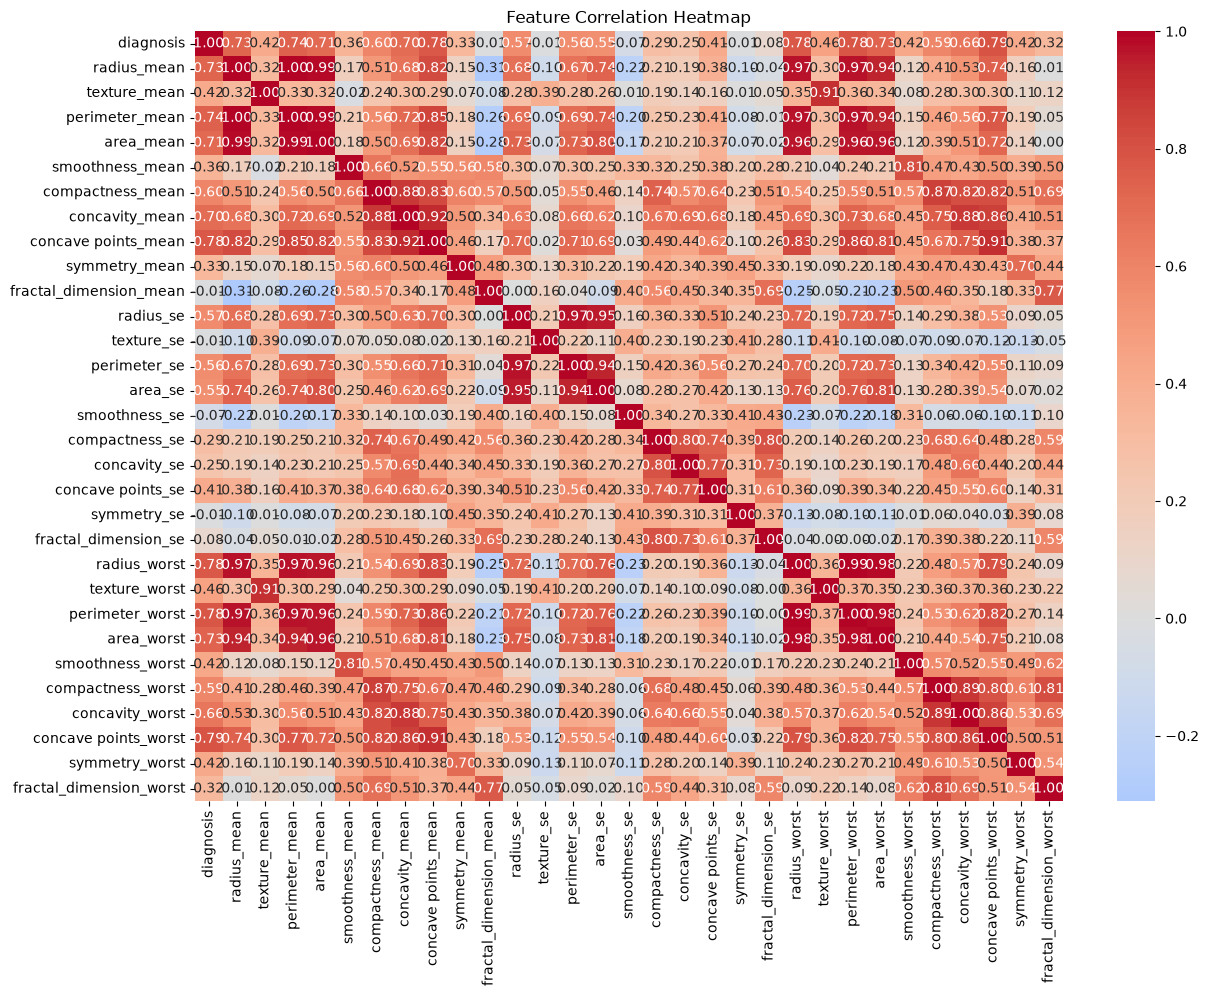

In [10]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(data):
    data_c = add_constant(data)
    vif = pd.Series(
        [variance_inflation_factor(data_c.values, i) for i in range(1, data_c.shape[1])],
        index=data.columns,
    )
    return vif.sort_values(ascending=False)

X_vif_check = df.drop(columns=["diagnosis"])
dropped_features = []
VIF_THRESHOLD = 10

while True:
    vif_scores = compute_vif(X_vif_check)
    if vif_scores.iloc[0] > VIF_THRESHOLD:
        worst_feature = vif_scores.index[0]
        dropped_features.append((worst_feature, round(vif_scores.iloc[0], 1)))
        X_vif_check = X_vif_check.drop(columns=[worst_feature])
    else:
        break

print(f"Dropped {len(dropped_features)} of {df.shape[1]-1} features (VIF > {VIF_THRESHOLD}):")
for name, vif_val in dropped_features:
    print(f"  {name:<25} VIF={vif_val}")

print(f"\nKept {X_vif_check.shape[1]} features:")
print(list(X_vif_check.columns))

print("\nFinal VIF scores (all should be under the threshold):")
print(compute_vif(X_vif_check).round(2))


Dropped 13 of 30 features (VIF > 10):
  radius_mean               VIF=3806.1
  radius_worst              VIF=616.4
  perimeter_mean            VIF=325.6
  perimeter_worst           VIF=123.3
  concavity_mean            VIF=64.7
  radius_se                 VIF=35.6
  compactness_worst         VIF=34.0
  concave points_worst      VIF=30.6
  area_mean                 VIF=25.4
  compactness_mean          VIF=18.8
  texture_worst             VIF=17.2
  area_se                   VIF=16.3
  concavity_worst           VIF=15.5

Kept 17 features:
['texture_mean', 'smoothness_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'area_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']

Final VIF scores (all should be under the threshold):
concave points_mean        8.98
area_worst                 8.68
fractal_dimensio

## Prepare the dataset

In [12]:
X = X_vif_check.copy()  
y = df["diagnosis"]
print(X.shape,y.shape)

(569, 17) (569,)


## Train Test Split

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42, stratify = y)

In [14]:
y_train.value_counts()

diagnosis
0    285
1    170
Name: count, dtype: int64

There is imbalance in dataset .The model may be biased towards the benign

Methods to balance the data set - Random sampler - Random Over Sampler & Radom Under Sampler, SMOTE

## Random Over Sampler

In [15]:
from imblearn.over_sampling import RandomOverSampler

In [16]:
ros = RandomOverSampler(random_state = 42)
X_train_ba1l,y_train_bal1 = ros.fit_resample(X_train,y_train)
print(y_train_bal1.value_counts())

diagnosis
1    285
0    285
Name: count, dtype: int64


## Random Under Sampler

In [17]:
from imblearn.under_sampling import RandomUnderSampler

In [18]:
rus = RandomUnderSampler(random_state = 42)
X_train_bal2,y_train_bal2 = rus.fit_resample(X_train,y_train)
print(y_train_bal2.value_counts())

diagnosis
0    170
1    170
Name: count, dtype: int64


## SMOTE - Synthetic Minority Over Sampling Technique

In [19]:
from imblearn.over_sampling import SMOTE

In [20]:
smote = SMOTE(random_state = 42)
X_train_bal,y_train_bal = smote.fit_resample(X_train,y_train)
print(y_train_bal.value_counts())
print("Shape before balancing:",X_train.shape)
print("Shape after balancing:",X_train_bal.shape)

diagnosis
1    285
0    285
Name: count, dtype: int64
Shape before balancing: (455, 17)
Shape after balancing: (570, 17)


## Numerical Transformer - Standard Scalar

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

## 1st Model - Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
log_model = LogisticRegression(max_iter = 1000,random_state = 42)
log_model.fit(X_train_scaled,y_train_bal)
y_pred = log_model.predict(X_test_scaled)

### Evaluate the model

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score, roc_auc_score

In [26]:
print("Accuracy:\n",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Precision Score:\n",precision_score(y_test,y_pred))
print("f1 Score:\n",f1_score(y_test,y_pred))
print("Recall Score:\n",recall_score(y_test,y_pred))
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.956140350877193
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        72
           1       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[70  2]
 [ 3 39]]
Precision Score:
 0.9512195121951219
f1 Score:
 0.9397590361445783
Recall Score:
 0.9285714285714286
ROC AUC Score:
 0.9927248677248677


## 2nd model - KNN (K-Nearest Neighbors)

In [27]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled,y_train_bal)
y_pred_knn = knn_model.predict(X_test_scaled)

### Evaluate the KNN model

In [29]:
print("Accuracy:\n",accuracy_score(y_test,y_pred_knn))
print("Classification Report:\n",classification_report(y_test,y_pred_knn))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("Precision Score:\n",precision_score(y_test,y_pred_knn))
print("f1 Score:\n",f1_score(y_test,y_pred_knn))
print("Recall Score:\n",recall_score(y_test,y_pred_knn))
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob_knn)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9210526315789473
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94        72
           1       0.90      0.88      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

Confusion Matrix:
 [[68  4]
 [ 5 37]]
Precision Score:
 0.9024390243902439
f1 Score:
 0.891566265060241
Recall Score:
 0.8809523809523809
ROC AUC Score:
 0.984457671957672


## 3rd Model - Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train_scaled,y_train_bal)
y_pred_dt = dt_model.predict(X_test_scaled)

### Evaluate the Dicision Tree model

In [32]:
print("Accuracy:\n",accuracy_score(y_test,y_pred_dt))
print("Classification Report:\n",classification_report(y_test,y_pred_dt))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_dt))
print("Precision Score:\n",precision_score(y_test,y_pred_dt))
print("f1 Score:\n",f1_score(y_test,y_pred_dt))
print("Recall Score:\n",recall_score(y_test,y_pred_dt))
y_prob_df = dt_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob_df)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9122807017543859
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93        72
           1       0.92      0.83      0.88        42

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114

Confusion Matrix:
 [[69  3]
 [ 7 35]]
Precision Score:
 0.9210526315789473
f1 Score:
 0.875
Recall Score:
 0.8333333333333334
ROC AUC Score:
 0.8958333333333335


## 4th Model - Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train_scaled,y_train_bal)
y_pred_rf= rf_model.predict(X_test_scaled)

### Evaluate the model

In [35]:
print("Accuracy:\n",accuracy_score(y_test,y_pred_rf))
print("Classification Report:\n",classification_report(y_test,y_pred_rf))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_rf))
print("Precision Score:\n",precision_score(y_test,y_pred_rf))
print("f1 Score:\n",f1_score(y_test,y_pred_rf))
print("Recall Score:\n",recall_score(y_test,y_pred_rf))
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob_rf)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.956140350877193
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[71  1]
 [ 4 38]]
Precision Score:
 0.9743589743589743
f1 Score:
 0.9382716049382716
Recall Score:
 0.9047619047619048
ROC AUC Score:
 0.99619708994709


## Comparing All Four Models Side by Side.

In [36]:
from sklearn.metrics import roc_curve

summary_rows = [
    {"Model": "Logistic Regression", 
     "Accuracy": accuracy_score(y_test, y_pred),
     "Precision": precision_score(y_test, y_pred), 
     "Recall": recall_score(y_test, y_pred),
     "F1": f1_score(y_test, y_pred), 
     "ROC AUC": roc_auc_score(y_test, y_prob)},
    {"Model": "KNN", 
     "Accuracy": accuracy_score(y_test, y_pred_knn),
     "Precision": precision_score(y_test, y_pred_knn), 
     "Recall": recall_score(y_test, y_pred_knn),
     "F1": f1_score(y_test, y_pred_knn), 
     "ROC AUC": roc_auc_score(y_test, y_prob_knn)},
    {"Model": "Decision Tree", 
     "Accuracy": accuracy_score(y_test, y_pred_dt),
     "Precision": precision_score(y_test, y_pred_dt), 
     "Recall": recall_score(y_test, y_pred_dt),
     "F1": f1_score(y_test, y_pred_dt), 
     "ROC AUC": roc_auc_score(y_test, y_prob_df)},
    {"Model": "Random Forest", 
     "Accuracy": accuracy_score(y_test, y_pred_rf),
     "Precision": precision_score(y_test, y_pred_rf), 
     "Recall": recall_score(y_test, y_pred_rf),
     "F1": f1_score(y_test, y_pred_rf), 
     "ROC AUC": roc_auc_score(y_test, y_prob_rf)}
    ]

model_comparison = pd.DataFrame(summary_rows).set_index("Model").round(4)
model_comparison.sort_values("Recall", ascending=False)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.9561,0.9512,0.9286,0.9398,0.9927
Random Forest,0.9561,0.9744,0.9048,0.9383,0.9962
KNN,0.9211,0.9024,0.8810,0.8916,0.9845
Decision Tree,0.9123,0.9211,0.8333,0.8750,0.8958


# Model Deployment

In [37]:
import joblib
joblib.dump(rf_model,"cancer_classification_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [38]:
model = joblib.load("cancer_classification_model.pkl")
scaler = joblib.load("scaler.pkl")

In [39]:
new_patient_dict = {
    "texture_mean": 17.5, "smoothness_mean": 0.095, "concave points_mean": 0.05,
    "symmetry_mean": 0.18, "fractal_dimension_mean": 0.06, "texture_se": 1.2,
    "perimeter_se": 2.5, "smoothness_se": 0.006, "compactness_se": 0.02,
    "concavity_se": 0.02, "concave points_se": 0.01, "symmetry_se": 0.02,
    "fractal_dimension_se": 0.003, "area_worst": 900.0, "smoothness_worst": 0.13,
    "symmetry_worst": 0.28, "fractal_dimension_worst": 0.08,
}

new_patient = pd.DataFrame([new_patient_dict])[X.columns]  # reindex guards against reordering

new_patient_scaled = scaler.transform(new_patient)
predict = model.predict(new_patient_scaled)
predict_proba = model.predict_proba(new_patient_scaled)[:, 1]
print("Predicted diagnosis:", "Malignant" if predict[0] == 1 else "Benign")
print(f"Predicted probability of malignancy: {predict_proba[0]:.3f}")

predict = model.predict(new_patient_scaled)
print("Predicted Class:",predict[0])

Predicted diagnosis: Benign
Predicted probability of malignancy: 0.430
Predicted Class: 0
